<a href="https://colab.research.google.com/github/ep42south-star/u8254334_EMSC2010-W10-P1/blob/main/EMSC2010_W10_L1_NB4_u8254334.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W10-L1-NB4

Use this notebook to process the Japanese cherry blossoms data and see if you can find a pattern in the long term data.

The excel data file ```blossom_doy.xlsx``` contains two variables:


1.   ```year```: The year of the cherry bloom.
2.   ```doy```: The day of the year of the first cherry bloom (where day 0 corresponds to January 1)

Don't forget to use the code in ```EMSC2010-W10-L1-NB2``` and ```EMSC2010-W10-L1-NB3``` as a template for this problem.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [13]:
data_file = 'blossom_doy.xlsx' #address of the data file
df = pd.read_excel(data_file) #read in the file
df.head() #show the header information

,year,doy
0,812,92
1,815,105
2,831,96
3,851,108
4,853,104


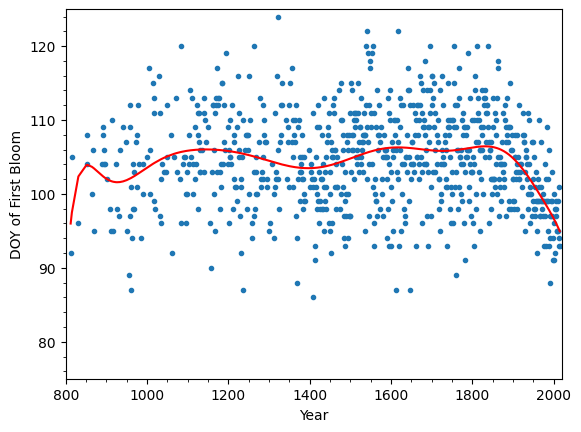

In [48]:
plt.plot('year', 'doy', '.', data=df)
plt.xlabel('Year')
plt.ylabel('Day of Year')
plt.minorticks_on()
plt.xlim([800,2020])
plt.ylim([75,125])

order = 12 #set the polynomial order
pp = np.polyfit(year,doy,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,year) #find the value of the polynomial at each time point.

plt.plot(year,trend,'r') #plot the trend
plt.xlabel('Year') #label the x-axis
plt.ylabel('DOY of First Bloom') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

In [49]:
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

In [50]:
w = 25 #length of the moving average
ys = moving_average(doy, w) #process the signal
ts = moving_average(year, w) #process the times

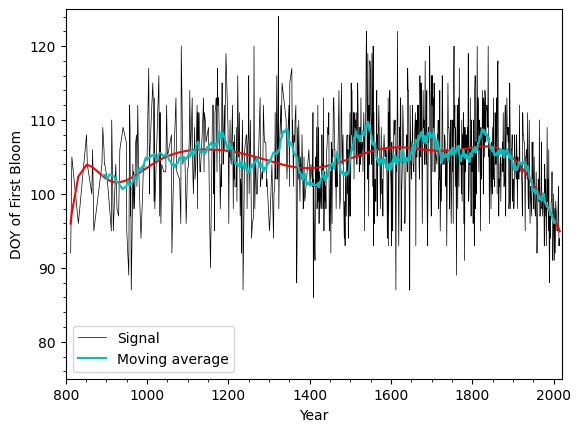

In [51]:
plt.plot(year,doy,'k',linewidth=0.5,label='Signal') #plot the noisy signal
plt.plot(year,trend,'r') #plot the trend
plt.plot(ts,ys,'c',label='Moving average') #plot the moving average
plt.xlim([800,2020]) #limit the x-axis
plt.ylim([75,125]) #limit the y-axis
plt.xlabel('Year') #label the x-axis
plt.ylabel('DOY of First Bloom') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks